In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : AlexNet With Batch Normalization – PyTorch
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [3]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [5]:
class AlexNet(nn.Module):
    def __init__(self,
                 in_channels1=1,
                 out_channels1=6,
                 kernel_size1=(5,5),stride_c1=(1,1),
                 pool_size1=(2,2),stride_p1=(2,2),
                 out_channels2=16,
                 kernel_size2=(3,3),stride_c2=(1,1),
                 pool_size2=(2,2),stride_p2=(2,2),
                 out_channels3=16,
                 kernel_size3=(3,3),stride_c3=(1,1),
                 out_channels4=16,
                 kernel_size4=(3,3),stride_c4=(1,1),
                 out_channels5=16,
                 kernel_size5=(3,3),stride_c5=(1,1),
                 pool_size3=(2,2),stride_p3=(2,2),
                 n_fc1=120,
                 n_fc2=84,
                 n_out=10):
        super(AlexNet, self).__init__()
        
        self.conv1= nn.Conv2d(in_channels=in_channels1,
                              out_channels=out_channels1,
                              kernel_size=kernel_size1,
                              padding=(kernel_size1[0]//2,kernel_size1[1]//2),
                              bias=True,
                              stride=stride_c1)
        self.bn1= nn.BatchNorm2d(num_features=out_channels1)
        
        self.pool1= nn.MaxPool2d(pool_size1,stride=stride_p1)
        self.conv2= nn.Conv2d(in_channels=out_channels1,
                              out_channels=out_channels2,
                              kernel_size=kernel_size2,
                              padding=(kernel_size2[0]//2,kernel_size2[1]//2),
                              bias=True,
                              stride=stride_c2)
        self.bn2= nn.BatchNorm2d(num_features=out_channels2)
        
        self.pool2= nn.MaxPool2d(pool_size2,stride=stride_p2)
        
        self.conv3= nn.Conv2d(in_channels=out_channels2,
                              out_channels=out_channels3,
                              kernel_size=kernel_size3,
                              padding=(kernel_size3[0]//2,kernel_size3[1]//2),
                              bias=True,
                              stride=stride_c3)
        self.bn3= nn.BatchNorm2d(num_features=out_channels3)
        
        self.conv4= nn.Conv2d(in_channels=out_channels3,
                              out_channels=out_channels4,
                              kernel_size=kernel_size4,
                              padding=(kernel_size4[0]//2,kernel_size4[1]//2),
                              bias=True,
                              stride=stride_c4)
        self.bn4= nn.BatchNorm2d(num_features=out_channels4)
        
        self.conv5= nn.Conv2d(in_channels=out_channels4,
                              out_channels=out_channels5,
                              kernel_size=kernel_size5,
                              padding=(kernel_size5[0]//2,kernel_size5[1]//2),
                              bias=True,
                              stride=stride_c5)
        self.bn5= nn.BatchNorm2d(num_features=out_channels5)
        
        self.pool3= nn.MaxPool2d(pool_size3,stride=stride_p3)
        
        in_features= out_channels5*(28//pool_size1[0]//2//2)*(28//pool_size1[1]//2//2)
        self.fc1= nn.Linear(in_features= in_features,
                        out_features= n_fc1)
        self.bn_fc1= nn.BatchNorm1d(num_features=n_fc1)
        self.fc2= nn.Linear(in_features= n_fc1,
                        out_features= n_fc2)
        self.bn_fc2= nn.BatchNorm1d(num_features=n_fc2)
        
        self.fc3= nn.Linear(in_features= n_fc2,
                        out_features= n_out,)
        
        self.fun= nn.ReLU()
        self.drop= nn.Dropout(0.3)
        # self.fun= nn.Sigmoid()
    
    def forward(self,X):
        # X: bs x 1 x H x W
        # convolution
        out= self.conv1(X)
        out= self.bn1(out)
        out= self.fun(out)
        out= self.pool1(out)
        
        out= self.conv2(out)
        out= self.bn2(out)
        out= self.fun(out)
        out= self.pool2(out)
        
        out= self.conv3(out)
        out= self.bn3(out)
        out= self.fun(out)
        
        out= self.conv4(out)
        out= self.bn4(out)
        out= self.fun(out)
        
        out= self.conv5(out)
        out= self.bn5(out)
        out= self.fun(out)
        
        out= self.pool3(out)
        
        # flatting
        flat= out.flatten(start_dim=1)# bs x n_features 
        # dense layer
        out= self.fc1(flat)# batch_size x n_out
        out= self.bn_fc1(out)
        out=  self.fun(out)
        out= self.drop(out)
        
        out= self.fc2(out)# batch_size x n_out
        out= self.bn_fc2(out)
        out=  self.fun(out)
        out= self.drop(out)
        
        out= self.fc3(out)# batch_size x n_out
        return out


In [ ]:
model= AlexNet( in_channels1=1,
                 out_channels1=6,
                 kernel_size1=(5,5),stride_c1=(1,1),
                 pool_size1=(2,2),stride_p1=(2,2),
                 out_channels2=16,
                 kernel_size2=(3,3),stride_c2=(1,1),
                 pool_size2=(2,2),stride_p2=(2,2),
                 out_channels3=16,
                 kernel_size3=(3,3),stride_c3=(1,1),
                 out_channels4=16,
                 kernel_size4=(3,3),stride_c4=(1,1),
                 out_channels5=16,
                 kernel_size5=(3,3),stride_c5=(1,1),
                 pool_size3=(2,2),stride_p3=(2,2),
                 n_fc1=120,#120,
                 n_fc2=84,#84,
                 n_out=10)

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

Loss(0:0): 2.407994 **** Valid Acc:9.620%
Loss(0:500): 0.470634 **** Valid Acc:97.180%
Loss(0:1000): 0.309028 **** Valid Acc:96.890%
Loss(0:1500): 0.247920 **** Valid Acc:97.580%
Loss(1:0): 0.095693 **** Valid Acc:98.430%
Loss(1:500): 0.099763 **** Valid Acc:98.470%
Loss(1:1000): 0.097656 **** Valid Acc:98.270%
Loss(1:1500): 0.095554 **** Valid Acc:98.210%


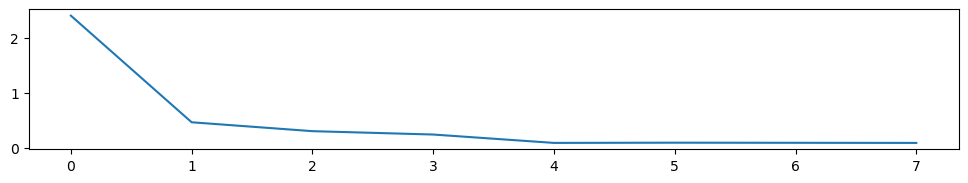

In [7]:
cost=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               cost.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'Loss({iter}:{i}): {loss:.6f} **** Valid Acc:{accuracy:.3f}%')
               model.train()
cost=torch.tensor(cost)
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

Total accuracy:98.120%
accuracy0:98.980%
accuracy1:98.767%
accuracy2:97.190%
accuracy3:99.604%
accuracy4:97.251%
accuracy5:96.749%
accuracy6:97.912%
accuracy7:98.541%
accuracy8:98.563%
accuracy9:97.423%


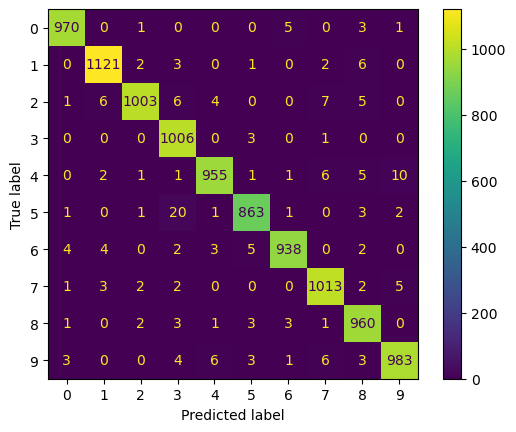

In [8]:
# validation
y_pred=[]
y_true=[]
for i,(xbatch,ybatch) in enumerate(test_loader):
    # farward pass
    ypred= model(xbatch)
    ypred= torch.argmax(ypred,dim=1)
    y_pred.extend(ypred.numpy())
    y_true.extend(ybatch.numpy())
    
y_pred= np.array(y_pred)
y_true= np.array(y_true)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(y_true,y_pred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(C.shape[0]):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()